In [1]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()

In [3]:
holding_period = 65
tickers = sp500["ticker"].values
positions = len(sp500["GICS Sector"].unique())
training_year = 2013
training_years = 1

In [4]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices.copy()
        simulation.sort_values("date",inplace=True)
        simulation["return"] = (simulation["adjclose"] - simulation["adjclose"].shift(holding_period)) / simulation["adjclose"].shift(holding_period)
        simulation["risk"] = simulation["adjclose"].rolling(holding_period).std() / simulation["adjclose"].rolling(holding_period).mean()
        # simulation["abs"] = simulation["return"] / simulation["risk"]
        simulation["abs"] = simulation["return"]
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"].shift(-holding_period)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions)
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|████████████████▏                                                                                                            | 65/503 [00:13<01:17,  5.64it/s]

'date'


model_prep:  16%|███████████████████▉                                                                                                         | 80/503 [00:17<01:26,  4.87it/s]

'date'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [01:50<00:00,  4.56it/s]

'date'


In [16]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")

In [17]:
## backtest
trades = sim[sim["weekday"]==4].copy()
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = trades.sort_values("abs",ascending=False).groupby(["date","GICS Sector"]).first().reset_index()
# trades = trades.sort_values("abs",ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()

In [18]:
trades = processor.column_date_processing(trades[["date","abs","ticker","GICS Sector","adjclose","return"]])

In [19]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [20]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

In [21]:
portfolio

,date,return,cr,year,quarter,month,week,weekday,realtime_start,realtime_end,value,bcr
0,2013-12-27 00:00:00+00:00,1.088412,1.088412,2013,4,12,52,4,2023-12-03,2023-12-03,1841.40,1.000000
1,2014-03-28 00:00:00+00:00,1.120237,1.219279,2014,1,3,13,4,2023-12-03,2023-12-03,1857.62,1.008809
2,2014-06-27 00:00:00+00:00,1.024588,1.249258,2014,2,6,26,4,2023-12-03,2023-12-03,1960.96,1.064929
3,2014-09-26 00:00:00+00:00,1.078609,1.347461,2014,3,9,39,4,2023-12-03,2023-12-03,1982.85,1.076817
4,2014-12-26 00:00:00+00:00,1.040053,1.401432,2014,4,12,52,4,2023-12-03,2023-12-03,2088.77,1.134338
5,2015-03-27 00:00:00+00:00,1.018633,1.427545,2015,1,3,13,4,2023-12-03,2023-12-03,2061.02,1.119268
6,2015-06-26 00:00:00+00:00,0.875060,1.249188,2015,2,6,26,4,2023-12-03,2023-12-03,2101.49,1.141246
7,2015-09-25 00:00:00+00:00,1.105535,1.381021,2015,3,9,39,4,2023-12-03,2023-12-03,1931.34,1.048843
8,2016-04-01 00:00:00+00:00,1.090932,1.506601,2016,2,4,13,4,2023-12-03,2023-12-03,2072.78,1.125654
9,2016-07-01 00:00:00+00:00,0.994677,1.498581,2016,3,7,26,4,2023-12-03,2023-12-03,2102.95,1.142039


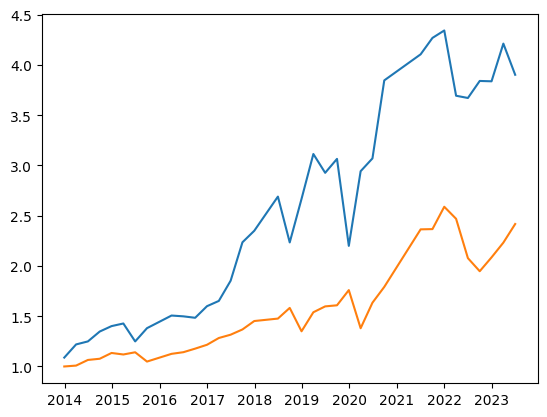

In [22]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [23]:
recommendations = trades.sort_values("date").tail(positions)

In [24]:
recommendations

,date,abs,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
394,2023-09-29 00:00:00+00:00,0.114784,DLR,Real Estate,121.020000,NaN,2023,3,9,39,4
385,2023-09-29 00:00:00+00:00,0.223796,CHTR,Communication Services,439.820000,NaN,2023,3,9,39,4
386,2023-09-29 00:00:00+00:00,0.167174,DPZ,Consumer Discretionary,378.790000,NaN,2023,3,9,39,4
387,2023-09-29 00:00:00+00:00,0.186098,BG,Consumer Staples,107.577198,NaN,2023,3,9,39,4
388,2023-09-29 00:00:00+00:00,0.321771,MPC,Energy,150.513990,NaN,2023,3,9,39,4
389,2023-09-29 00:00:00+00:00,0.303086,ZION,Financials,34.471361,NaN,2023,3,9,39,4
390,2023-09-29 00:00:00+00:00,0.224209,AMGN,Health Care,266.648619,NaN,2023,3,9,39,4
391,2023-09-29 00:00:00+00:00,0.176408,TXT,Industrials,78.140000,NaN,2023,3,9,39,4
392,2023-09-29 00:00:00+00:00,0.205548,WDC,Information Technology,45.630000,NaN,2023,3,9,39,4
393,2023-09-29 00:00:00+00:00,0.278346,WRK,Materials,35.518952,NaN,2023,3,9,39,4


In [25]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()